### **Polynomial Basis - No Normalization**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.loadtxt("data/noisy_2.txt")
data.shape

(10000, 2)

In [3]:
x = data[:, 0]
y = data[:, 1]

In [4]:
np.random.seed(42)

indices = np.random.permutation(len(x))

x_shuffled = x[indices]
y_shuffled = y[indices]

In [5]:
train_end = int(0.8 * len(x))

x_train = x_shuffled[:train_end]
y_train = y_shuffled[:train_end]

x_test = x_shuffled[train_end:]
y_test = y_shuffled[train_end:]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(8000,) (8000,)
(2000,) (2000,)


In [6]:
def polynomial_basis(x, degree):
    X = np.ones((len(x), degree + 1))

    for power in range(1, degree + 1):
        X[:, power] = x ** power

    return X

test_basis = polynomial_basis(x_train, degree=3)
test_basis[:3]

array([[ 1.00000000e+00,  2.50525053e+01,  6.27628019e+02,
         1.57236542e+04],
       [ 1.00000000e+00, -6.31063106e+00,  3.98240644e+01,
        -2.51314978e+02],
       [ 1.00000000e+00, -6.53765377e+01,  4.27409168e+03,
        -2.79425315e+05]])

In [7]:
# least squares 

def least_squares_solution(X, y):

    A = X.T @ X
    b = X.T @ y

    weights = np.linalg.inv(A) @ b
    return weights

In [8]:
# prediction y_pred

def predict(X, weights):
    
    y_pred = X @ weights
    return y_pred

In [9]:
# mse

def mse(y_actual, y_pred):
    return np.mean((y_actual - y_pred) ** 2)

In [10]:
degree = 10
X_train = polynomial_basis(x_train, degree)
X_test = polynomial_basis(x_test, degree)
weights_d10 = least_squares_solution(X_train, y_train)
y_train_pred = predict(X_train, weights_d10)
y_test_pred = predict(X_test, weights_d10)

In [11]:
print(weights_d10)

[ 3.94711488e+01  6.01412547e-01 -8.62333255e-02 -6.17247286e-04
  3.59594315e-05  1.62339175e-07 -4.61851295e-09 -1.29307065e-11
  1.63800801e-13  1.64259986e-16  2.45728460e-18]


The weights in the un-normalized version is very small, becauase they have to compensate for the scale of the large magnitudes of the features.

In [12]:
print(f"Train MSE : {mse(y_train, y_train_pred):.4f}")
print(f"Test MSE : {mse(y_test, y_test_pred):.4f}")

Train MSE : 360.4778
Test MSE : 340.0071


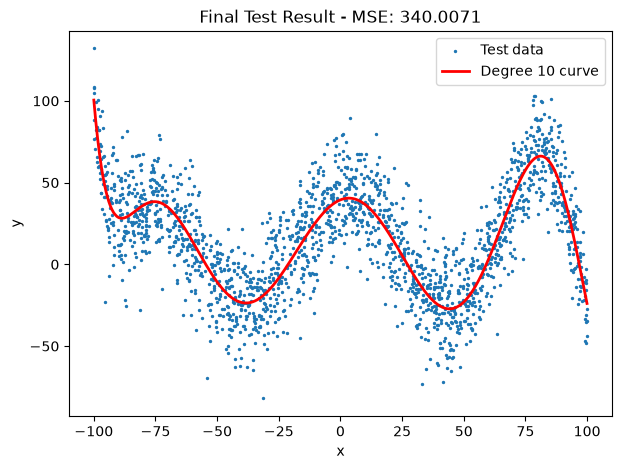

In [13]:
test_order = np.argsort(x_test)

plt.figure(figsize=(7, 5))
plt.scatter(x_test, y_test, s=2, label="Test data")
plt.plot(x_test[test_order], y_test_pred[test_order], color="red", linewidth=2, label="Degree 10 curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Unnormalized Polynomial Test Result - MSE: {mse(y_test, y_test_pred):.4f}")
plt.legend()
plt.savefig("../docs/lab3/submissions/figures/unnormalized_polynomial_test_fit.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

Polynomial Basis without normalization and with normalization yields the same result actually. All they bring to the table is improving numerical stability and reducing floating point precision problems.

### **Gaussian Basis**

In [14]:
train_end = int(0.6 * len(x))
val_end = int(0.8 * len(x))    

x_train = x_shuffled[:train_end]
y_train = y_shuffled[:train_end]

x_val = x_shuffled[train_end:val_end]
y_val = y_shuffled[train_end:val_end]

x_test = x_shuffled[val_end:]
y_test = y_shuffled[val_end:]

In [15]:
# gaussian basis function

def gaussian_basis(x, centers, sigma):
    X = np.ones((len(x), len(centers) + 1))

    for i in range(len(centers)):
        X[:, i+1] = np.exp(-0.5 * ((x - centers[i]) / sigma) ** 2)

    return X

In [ ]:
# equally spaced centers and sigma

centers = np.linspace(min(x_train), max(x_train), 10)
sigma = centers[1] - centers[0]

In [24]:
X_train_gaussian = gaussian_basis(x_train, centers, sigma)
X_val_gaussian = gaussian_basis(x_val, centers, sigma)

In [25]:
gaussian_weights = least_squares_solution(X_train_gaussian, y_train)
y_train_pred_gaussian = predict(X_train_gaussian, gaussian_weights)
y_val_pred_gaussian = predict(X_val_gaussian, gaussian_weights)

In [26]:
print(f"Train MSE (Gaussian Basis): {mse(y_train, y_train_pred_gaussian):.4f}")
print(f"Validation MSE (Gaussian Basis): {mse(y_val, y_val_pred_gaussian):.4f}")

Train MSE (Gaussian Basis): 394.7740
Validation MSE (Gaussian Basis): 378.8815


In [33]:
center_counts = [5, 10, 15, 20, 25, 30, 35]

train_mse_list = []
val_mse_list = []

for count in center_counts:
    centers = np.linspace(min(x_train), max(x_train), count)
    sigma = centers[1] - centers[0]

    X_train_gaussian = gaussian_basis(x_train, centers, sigma)
    X_val_gaussian = gaussian_basis(x_val, centers, sigma)

    weights = least_squares_solution(X_train_gaussian, y_train)
    y_train_pred = predict(X_train_gaussian, weights)
    y_val_pred = predict(X_val_gaussian, weights)

    train_mse_list.append(mse(y_train, y_train_pred))
    val_mse_list.append(mse(y_val, y_val_pred))

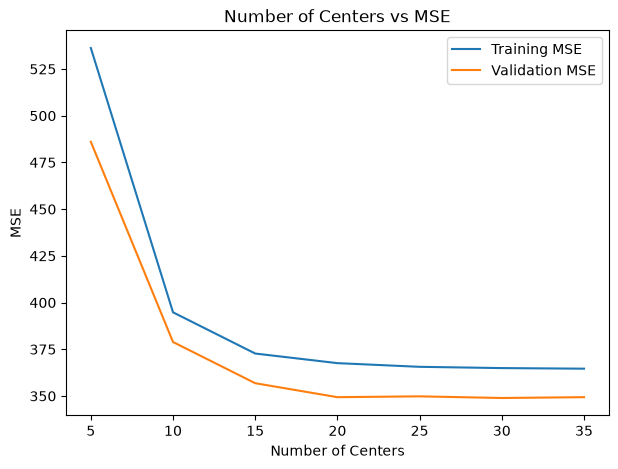

Best Number of Centers : 30


In [34]:
plt.figure(figsize=(7, 5))
plt.plot(center_counts, train_mse_list, label="Training MSE")
plt.plot(center_counts, val_mse_list, label="Validation MSE")
plt.xlabel("Number of Centers")
plt.ylabel("MSE")
plt.title("Number of Centers vs MSE")
plt.legend()
plt.savefig("../docs/lab3/submissions/figures/gaussian_center_mse_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

best_center_count = center_counts[np.argmin(val_mse_list)]
print(f"Best Number of Centers : {best_center_count}")

In [35]:
x_train_final = np.concatenate((x_train, x_val))
y_train_final = np.concatenate((y_train, y_val))

centers = np.linspace(min(x_train_final), max(x_train_final), best_center_count)
sigma = centers[1] - centers[0]
 
X_train_final_gaussian = gaussian_basis(x_train_final, centers, sigma)
final_weights = least_squares_solution(X_train_final_gaussian, y_train_final)


X_test_final_gaussian = gaussian_basis(x_test, centers, sigma)
y_test_pred = predict(X_test_final_gaussian, final_weights)

print(f"Final Test MSE : {mse(y_test, y_test_pred):.4f}")

Final Test MSE : 342.1092


In [36]:
print(final_weights)

[  96.84107696   54.08258301 -101.88647453   22.99769583  -57.4592708
    4.48819077  -46.41455047  -19.22043614  -51.03457052  -45.13018259
  -51.15119272  -46.74651327  -44.07733475  -30.67380811  -33.7867705
  -15.73783441  -28.46263728  -11.91968078  -39.78092856  -23.9016143
  -56.11706862  -35.99164486  -66.02391644  -31.34903465  -62.66459347
   -5.84552292  -44.1220284    27.46788182  -55.16166537   39.33299599
 -130.58516767]


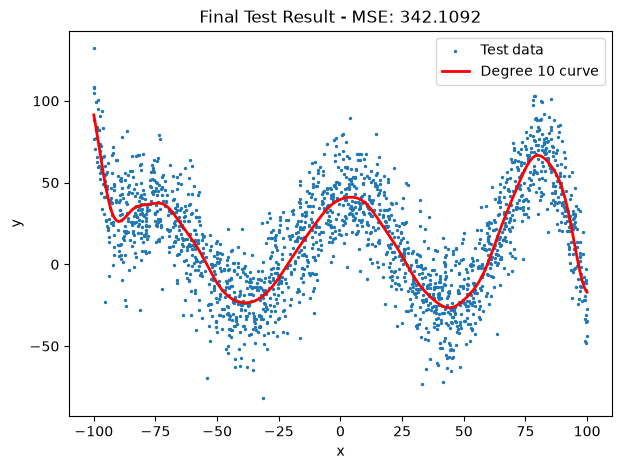

In [37]:
test_order = np.argsort(x_test)

plt.figure(figsize=(7, 5))
plt.scatter(x_test, y_test, s=2, label="Test data")
plt.plot(x_test[test_order], y_test_pred[test_order], color="red", linewidth=2, label=f"Gaussian curve - {best_center_count} centers")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Gaussian Test Result - MSE: {mse(y_test, y_test_pred):.4f}")
plt.legend()
plt.savefig("../docs/lab3/submissions/figures/gaussian_test_fit.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()